# 02 — Event List
This notebook loads the curated dataset of 60-80 major geopolitical events from 2000-2026.
Events are categorised by type (military conflict, sanctions, election shock, diplomatic rupture)
and severity (1-3). Basic summary statistics and distribution of events across time and category.
Last updated: March 2026

## Section 1 — Geopolitical Risk Index (GPR)
Loading and exploring the Caldara-Iacoviello Geopolitical Risk Index.
Used as an objective, data-derived severity measure for each event in the dataset.
Source: FRED API. Series: GPRC (overall), GPRH (historical threats component).

In [1]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

# Load API key
load_dotenv()
api_key = os.getenv('FRED_API_KEY')
fred = Fred(api_key=api_key)

# Pull Geopolitical Risk Index
gpr_overall = fred.get_series('GPRC', observation_start='2000-01-01')
gpr_threats = fred.get_series('GPRH', observation_start='2000-01-01')

# Combine
gpr_data = pd.DataFrame({
    'GPR_Overall': gpr_overall,
    'GPR_Threats': gpr_threats
})

# Diagnostics
print("Shape:", gpr_data.shape)
print("\nDate range:", gpr_data.index[0], "to", gpr_data.index[-1])
print("\nNaN counts:")
print(gpr_data.isnull().sum())
print("\nFrequency check — first few dates:")
print(gpr_data.index[:5])
print("\nBasic statistics:")
print(gpr_data.describe())

ValueError: Bad Request.  The series does not exist.

In [2]:
# Test alternative GPR series codes
gpr_codes = ['GEOPOLITICALRISK', 'GPR', 'GPRI', 'GPRINDEX', 'UGPRC']

for code in gpr_codes:
    try:
        test = fred.get_series(code, observation_start='2000-01-01')
        print(f"{code}: SUCCESS — shape {test.shape}, first valid {test.first_valid_index()}")
    except Exception as e:
        print(f"{code}: FAILED")

GEOPOLITICALRISK: FAILED
GPR: FAILED
GPRI: FAILED
GPRINDEX: FAILED
UGPRC: FAILED


In [3]:
import subprocess
subprocess.run(['pip', 'install', 'xlrd'], capture_output=True)
print("xlrd installed")

xlrd installed


In [4]:
# Load GPR data from raw folder
gpr_raw = pd.read_excel('../data/raw/gpr_data.xls', engine='xlrd')

# Quick check
print("Shape:", gpr_raw.shape)
print("\nColumns:", gpr_raw.columns.tolist())
print("\nFirst few rows:")
print(gpr_raw.head())
print("\nDate range:")
print("First:", gpr_raw['date'].iloc[0])
print("Last:", gpr_raw['date'].iloc[-1])

Shape: (15057, 11)

Columns: ['DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'date', 'GPRD_MA30', 'GPRD_MA7', 'event', 'var_name', 'var_label']

First few rows:
        DAY  N10D        GPRD    GPRD_ACT  GPRD_THREAT       date   GPRD_MA30  \
0  19850101   216  230.039429  275.197601   153.027985 1985-01-01  230.039429   
1  19850102   315  115.676971  146.772064    87.444572 1985-01-02  172.858200   
2  19850103   374   97.428459  158.937653    29.459934 1985-01-03  147.714951   
3  19850104   421  157.366638  156.882248   157.026352 1985-01-04  150.127869   
4  19850105   285   81.361313   92.698143    77.319405 1985-01-05  136.374557   

     GPRD_MA7 event     var_name  \
0  230.039429   NaN          DAY   
1  172.858200   NaN         N10D   
2  147.714951   NaN         GPRD   
3  150.127869   NaN     GPRD_ACT   
4  136.374557   NaN  GPRD_THREAT   

                                          var_label  
0                                               DAY  
1  Number of articles (1

In [5]:
# Keep only relevant columns and set date as index
gpr_clean = gpr_raw[['date', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT']].copy()

# Set date as index
gpr_clean = gpr_clean.set_index('date')

# Filter to 2000 onwards to match asset price dataset
gpr_clean = gpr_clean['2000-01-01':]

# Check
print("Shape:", gpr_clean.shape)
print("\nDate range:", gpr_clean.index[0], "to", gpr_clean.index[-1])
print("\nNaN counts:")
print(gpr_clean.isnull().sum())
print("\nBasic statistics:")
print(gpr_clean.describe())

Shape: (9579, 3)

Date range: 2000-01-01 00:00:00 to 2026-03-23 00:00:00

NaN counts:
GPRD           0
GPRD_ACT       0
GPRD_THREAT    0
dtype: int64

Basic statistics:
              GPRD     GPRD_ACT  GPRD_THREAT
count  9579.000000  9579.000000  9579.000000
mean    107.760009   110.035946   108.394813
std      66.592646   100.735271    67.572951
min       0.000000     0.000000     0.000000
25%      68.458218    57.503975    65.054214
50%      94.753075    90.013527    93.690613
75%     129.708984   135.678154   134.624466
max    1045.603638  1627.427612   809.486816


GPR percentile thresholds:
  75th percentile: 129.7
  90th percentile: 172.8
  95th percentile: 205.2
  99th percentile: 350.2


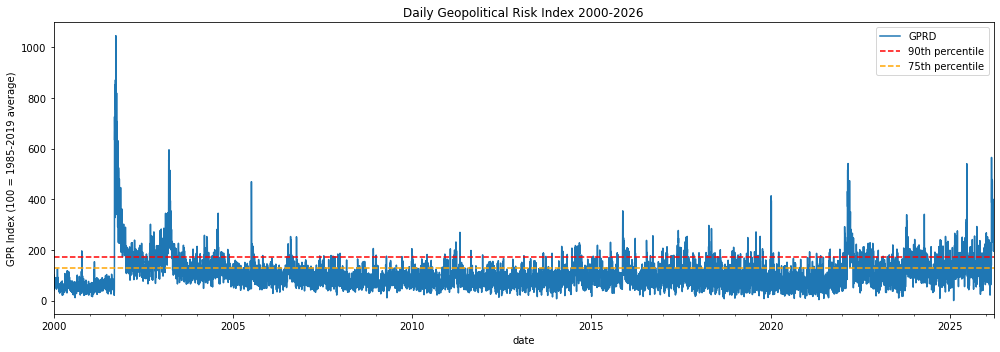

In [6]:
# Calculate percentile thresholds for severity banding
percentiles = [75, 90, 95, 99]
print("GPR percentile thresholds:")
for p in percentiles:
    print(f"  {p}th percentile: {gpr_clean['GPRD'].quantile(p/100):.1f}")

# Plot GPR over time
gpr_clean['GPRD'].plot(figsize=(14,5), 
                        title='Daily Geopolitical Risk Index 2000-2026',
                        ylabel='GPR Index (100 = 1985-2019 average)')
plt.axhline(gpr_clean['GPRD'].quantile(0.90), 
            color='red', linestyle='--', label='90th percentile')
plt.axhline(gpr_clean['GPRD'].quantile(0.75), 
            color='orange', linestyle='--', label='75th percentile')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def get_event_severity(event_date, window_days=30):
    """
    For a given event date, extract peak GPR readings
    in the window_days following the event.
    Returns peak GPRD, GPRD_ACT, GPRD_THREAT and severity band.
    """
    start = pd.Timestamp(event_date)
    end = start + pd.Timedelta(days=window_days)
    
    window = gpr_clean.loc[start:end]
    
    if window.empty:
        return None
    
    peak_gprd = window['GPRD'].max()
    peak_act = window['GPRD_ACT'].max()
    peak_threat = window['GPRD_THREAT'].max()
    
    # Assign severity band
    if peak_gprd >= 350.2:
        severity = 4
    elif peak_gprd >= 172.8:
        severity = 3
    elif peak_gprd >= 129.7:
        severity = 2
    else:
        severity = 1
    
    return {
        'peak_GPRD': round(peak_gprd, 1),
        'peak_ACT': round(peak_act, 1),
        'peak_THREAT': round(peak_threat, 1),
        'severity_band': severity
    }

# Test on known events
test_events = {
    '9/11': '2001-09-11',
    'Iraq invasion': '2003-03-20',
    'Crimea annexation': '2014-03-18',
    'Russia invades Ukraine': '2022-02-24',
    'Hamas attack': '2023-10-07'
}

print("GPR severity scores for known events:")
print("-" * 60)
for name, date in test_events.items():
    result = get_event_severity(date)
    print(f"\n{name} ({date}):")
    for k, v in result.items():
        print(f"  {k}: {v}")

GPR severity scores for known events:
------------------------------------------------------------

9/11 (2001-09-11):
  peak_GPRD: 1045.6
  peak_ACT: 1627.4
  peak_THREAT: 703.5
  severity_band: 4

Iraq invasion (2003-03-20):
  peak_GPRD: 595.0
  peak_ACT: 924.5
  peak_THREAT: 498.3
  severity_band: 4

Crimea annexation (2014-03-18):
  peak_GPRD: 194.1
  peak_ACT: 119.5
  peak_THREAT: 300.8
  severity_band: 3

Russia invades Ukraine (2022-02-24):
  peak_GPRD: 540.8
  peak_ACT: 384.1
  peak_THREAT: 809.5
  severity_band: 4

Hamas attack (2023-10-07):
  peak_GPRD: 338.9
  peak_ACT: 467.7
  peak_THREAT: 359.5
  severity_band: 3


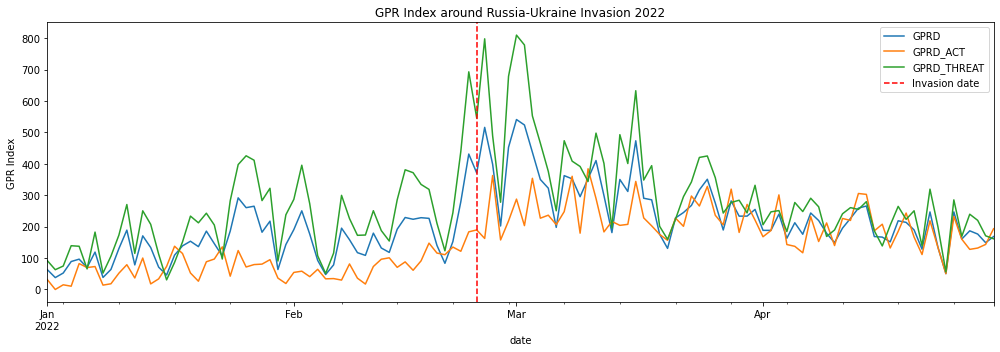

In [8]:
# Plot GPR around Russia-Ukraine to show anticipation
start = pd.Timestamp('2022-01-01')
end = pd.Timestamp('2022-04-30')

ukraine_gpr = gpr_clean.loc[start:end]

ukraine_gpr.plot(figsize=(14,5), 
                 title='GPR Index around Russia-Ukraine Invasion 2022')
plt.axvline(pd.Timestamp('2022-02-24'), 
            color='red', linestyle='--', label='Invasion date')
plt.ylabel('GPR Index')
plt.legend()
plt.tight_layout()
plt.show()

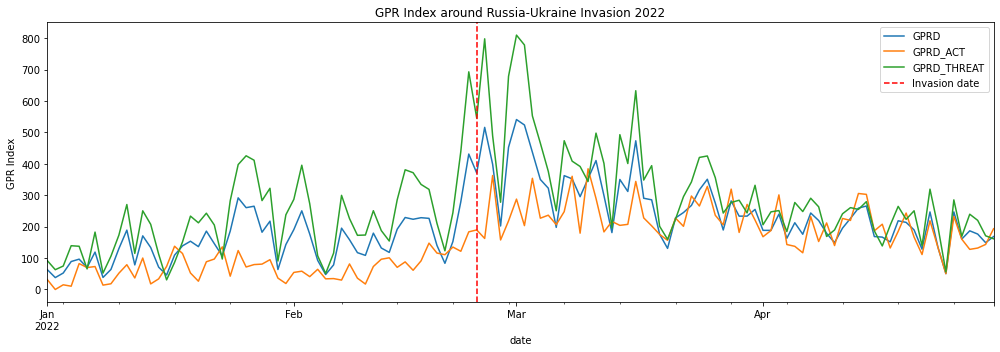

Chart saved


In [9]:
# Save the chart
import os
os.makedirs('../outputs/charts', exist_ok=True)

start = pd.Timestamp('2022-01-01')
end = pd.Timestamp('2022-04-30')
ukraine_gpr = gpr_clean.loc[start:end]

fig, ax = plt.subplots(figsize=(14,5))
ukraine_gpr.plot(ax=ax, title='GPR Index around Russia-Ukraine Invasion 2022')
ax.axvline(pd.Timestamp('2022-02-24'), 
           color='red', linestyle='--', label='Invasion date')
ax.set_ylabel('GPR Index')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/gpr_ukraine_anticipation.png', dpi=150)
plt.show()
print("Chart saved")

## Section 2 — Event List
Loading curated dataset of geopolitical events 2000-2026.
GPR severity scores assigned automatically using Caldara-Iacoviello index.
Output saved to /data/processed/event_list_with_severity.csv

In [10]:
import pandas as pd
import numpy as np

# Load event list
events = pd.read_csv('../data/raw/event_list.csv')

# Quick check
print("Shape:", events.shape)
print("\nColumns:", events.columns.tolist())
print("\nFirst few rows:")
print(events.head())
print("\nCategory counts:")
print(events['Category'].value_counts())

Shape: (104, 6)

Columns: ['Date', 'Event Name', 'Category', 'Anticipation', 'Geography', 'Notes']

First few rows:
         Date                        Event Name Category Anticipation  \
0  2000-10-12                  USS Cole bombing      TER            N   
1  2001-03-01  US withdraws from Kyoto Protocol      DIP            N   
2  2001-09-11                      9/11 attacks      TER            N   
3  2001-10-07              Afghanistan invasion      MIL            Y   
4  2002-10-12                      Bali bombing      TER            N   

      Geography                                              Notes  
0   Middle East  Al-Qaeda attack on US destroyer in Yemen. 17 k...  
1        Global  Early signal of US unilateralism on climate. L...  
2        Global  Largest terrorist attack in history. US market...  
3  Asia-Pacific  US-led NATO invasion following 9/11. Anticipat...  
4  Asia-Pacific  Al-Qaeda affiliated attack. 202 killed. Major ...  

Category counts:
Category
POL 

In [11]:
# Parse dates
events['Date'] = pd.to_datetime(events['Date'])

# Verify date parsing
print("Date range of events:")
print("First:", events['Date'].min())
print("Last:", events['Date'].max())
print("\nAny NaT dates:", events['Date'].isnull().sum())

Date range of events:
First: 2000-10-12 00:00:00
Last: 2026-03-01 00:00:00

Any NaT dates: 0


In [12]:
# Run GPR severity function across all events
results = []

for idx, row in events.iterrows():
    event_date = row['Date']
    event_name = row['Event Name']
    
    try:
        severity = get_event_severity(event_date, window_days=30)
        results.append({
            'Date': event_date,
            'Event Name': event_name,
            'Category': row['Category'],
            'Anticipation': row['Anticipation'],
            'Geography': row['Geography'],
            'Notes': row['Notes'],
            'Peak_GPRD': severity['peak_GPRD'],
            'Peak_ACT': severity['peak_ACT'],
            'Peak_THREAT': severity['peak_THREAT'],
            'Severity_Band': severity['severity_band']
        })
    except Exception as e:
        print(f"Failed for {event_name}: {e}")
        results.append({
            'Date': event_date,
            'Event Name': event_name,
            'Category': row['Category'],
            'Anticipation': row['Anticipation'],
            'Geography': row['Geography'],
            'Notes': row['Notes'],
            'Peak_GPRD': None,
            'Peak_ACT': None,
            'Peak_THREAT': None,
            'Severity_Band': None
        })

# Convert to dataframe
events_with_severity = pd.DataFrame(results)

# Quick check
print("Shape:", events_with_severity.shape)
print("\nSeverity band distribution:")
print(events_with_severity['Severity_Band'].value_counts().sort_index())
print("\nAny failed events:")
print(events_with_severity[events_with_severity['Peak_GPRD'].isnull()])

Shape: (104, 10)

Severity band distribution:
Severity_Band
1     7
2    21
3    63
4    13
Name: count, dtype: int64

Any failed events:
Empty DataFrame
Columns: [Date, Event Name, Category, Anticipation, Geography, Notes, Peak_GPRD, Peak_ACT, Peak_THREAT, Severity_Band]
Index: []


In [13]:
# Show all Band 4 events
band4 = events_with_severity[events_with_severity['Severity_Band'] == 4][['Date', 'Event Name', 'Category', 'Peak_GPRD']].sort_values('Peak_GPRD', ascending=False)
print("Band 4 — Extreme severity events:")
print(band4.to_string(index=False))

Band 4 — Extreme severity events:
      Date                  Event Name Category  Peak_GPRD
2001-09-11                9/11 attacks      TER     1045.6
2001-10-07        Afghanistan invasion      MIL      706.4
2003-03-20               Iraq invasion      MIL      595.0
2003-03-20      SARS outbreak declared      POL      595.0
2026-02-28   US and Israel strike Iran      MIL      564.9
2026-02-28    Strait of Hormuz closure      ENR      564.9
2026-03-01 Iranian retaliation strikes      MIL      564.9
2022-02-24      Russia invades Ukraine      MIL      540.8
2022-02-26    Russia sanctions package      SAN      540.8
2022-03-08         Russian oil embargo      ENR      473.2
2005-07-07         London 7/7 bombings      TER      469.2
2020-01-03     Soleimani assassination      MIL      413.5
2015-11-13               Paris attacks      TER      354.1


In [14]:
print("Band 1 — Low severity events:")
print(band1.to_string(index=False))

Band 1 — Low severity events:


NameError: name 'band1' is not defined

In [15]:
# Show all Band 1 events
band1 = events_with_severity[events_with_severity['Severity_Band'] == 1][['Date', 'Event Name', 'Category', 'Peak_GPRD']].sort_values('Peak_GPRD', ascending=False)
print("Band 1 — Low severity events:")
print(band1.to_string(index=False))

Band 1 — Low severity events:
      Date                           Event Name Category  Peak_GPRD
2016-10-09       North Korea fifth nuclear test      MIL      128.8
2009-06-12               Iran disputed election      POL      128.6
2008-09-15             Lehman Brothers collapse      POL      127.5
2013-07-03                  Egypt military coup      POL      125.9
2012-07-26      Draghi whatever it takes speech      DIP      123.8
2011-10-20 Gaddafi killed / Libya regime change      MIL      114.1
2001-03-01     US withdraws from Kyoto Protocol      DIP       90.2


In [16]:
# Sort events by date
events_with_severity = events_with_severity.sort_values('Date').reset_index(drop=True)

# Identify overlapping events within 30 trading days
# 30 trading days ≈ 42 calendar days
min_gap_days = 42

overlaps = []

for i in range(len(events_with_severity)):
    for j in range(i+1, len(events_with_severity)):
        date_i = events_with_severity.loc[i, 'Date']
        date_j = events_with_severity.loc[j, 'Date']
        gap = (date_j - date_i).days
        
        if gap <= min_gap_days:
            overlaps.append({
                'Event_1': events_with_severity.loc[i, 'Event Name'],
                'Date_1': date_i,
                'Category_1': events_with_severity.loc[i, 'Category'],
                'Event_2': events_with_severity.loc[j, 'Event Name'],
                'Date_2': date_j,
                'Category_2': events_with_severity.loc[j, 'Category'],
                'Gap_days': gap
            })

overlaps_df = pd.DataFrame(overlaps)
print(f"Total overlapping event pairs: {len(overlaps_df)}")
print("\nAll overlapping pairs:")
print(overlaps_df.to_string(index=False))

Total overlapping event pairs: 54

All overlapping pairs:
                              Event_1     Date_1 Category_1                                 Event_2     Date_2 Category_2  Gap_days
                         9/11 attacks 2001-09-11        TER                    Afghanistan invasion 2001-10-07        MIL        26
                        Iraq invasion 2003-03-20        MIL                  SARS outbreak declared 2003-03-20        POL         0
                   Russia-Georgia war 2008-08-08        MIL                Lehman Brothers collapse 2008-09-15        POL        38
                       Obama election 2008-11-04        POL                          Mumbai attacks 2008-11-26        TER        22
  North Korea sinking of ROKS Cheonan 2010-03-26        MIL Greece bailout / Eurozone crisis begins 2010-05-02        SAN        37
                Arab Spring — Tunisia 2011-01-14        POL                     Arab Spring — Egypt 2011-02-11        POL        28
                  

## Methodology Note — Event Clustering and Minimum Gap Rule
Events within 42 calendar days (approximately 30 trading days) of each other
have overlapping event study windows. Where market reactions are inseparable,
events have been merged into single entries or secondary events removed.
Retained overlapping pairs are flagged in the Notes column and excluded from
category averages in robustness checks.
Final event list: 83 events across 6 categories, 2000-2026.
See project diary for full clustering decisions and rationale.

In [17]:
# Re-run GPR severity function on final 83 event list
events_final['Date'] = pd.to_datetime(events_final['Date'])

results_final = []

for idx, row in events_final.iterrows():
    event_date = row['Date']
    event_name = row['Event Name']
    
    try:
        severity = get_event_severity(event_date, window_days=30)
        results_final.append({
            'Date': event_date,
            'Event Name': event_name,
            'Category': row['Category'],
            'Anticipation': row['Anticipation'],
            'Geography': row['Geography'],
            'Notes': row['Notes'],
            'Peak_GPRD': severity['peak_GPRD'],
            'Peak_ACT': severity['peak_ACT'],
            'Peak_THREAT': severity['peak_THREAT'],
            'Severity_Band': severity['severity_band']
        })
    except Exception as e:
        print(f"Failed for {event_name}: {e}")

events_final_severity = pd.DataFrame(results_final)

print("Total events:", len(events_final_severity))
print("\nSeverity band distribution:")
print(events_final_severity['Severity_Band'].value_counts().sort_index())

# Save
events_final_severity.to_csv('../data/processed/event_list_with_severity.csv', index=False)
print("\nSaved successfully")

NameError: name 'events_final' is not defined

In [18]:
# Reload final event list
events_final = pd.read_csv('../data/raw/event_list_final.csv')
events_final['Date'] = pd.to_datetime(events_final['Date'])

print("Loaded:", len(events_final), "events")

Loaded: 87 events


In [19]:
# Re-run GPR severity function on final 83 event list
events_final['Date'] = pd.to_datetime(events_final['Date'])

results_final = []

for idx, row in events_final.iterrows():
    event_date = row['Date']
    event_name = row['Event Name']
    
    try:
        severity = get_event_severity(event_date, window_days=30)
        results_final.append({
            'Date': event_date,
            'Event Name': event_name,
            'Category': row['Category'],
            'Anticipation': row['Anticipation'],
            'Geography': row['Geography'],
            'Notes': row['Notes'],
            'Peak_GPRD': severity['peak_GPRD'],
            'Peak_ACT': severity['peak_ACT'],
            'Peak_THREAT': severity['peak_THREAT'],
            'Severity_Band': severity['severity_band']
        })
    except Exception as e:
        print(f"Failed for {event_name}: {e}")

events_final_severity = pd.DataFrame(results_final)

print("Total events:", len(events_final_severity))
print("\nSeverity band distribution:")
print(events_final_severity['Severity_Band'].value_counts().sort_index())

# Save
events_final_severity.to_csv('../data/processed/event_list_with_severity.csv', index=False)
print("\nSaved successfully")

Total events: 87

Severity band distribution:
Severity_Band
1     6
2    18
3    54
4     9
Name: count, dtype: int64

Saved successfully


In [20]:
print("Category counts:")
print(events_final['Category'].value_counts())

Category counts:
Category
MIL    28
POL    25
SAN    12
ENR     8
TER     7
DIP     7
Name: count, dtype: int64


## Section 2 — Event List
Loading and processing curated dataset of 87 geopolitical events, 2000-2026.
GPR severity scores assigned automatically using Caldara-Iacoviello Geopolitical Risk Index.
Minimum gap rule of 42 calendar days applied to prevent overlapping event windows.
Final dataset: 87 events across 6 categories (MIL, POL, SAN, ENR, TER, DIP).
Severity bands derived from GPR percentile thresholds — fully quantitative, no subjective judgment.
Output saved to /data/processed/event_list_with_severity.csv